
# Task VII — Alpha-Consistency Physics-Token PINN (Kaggle-ready)

This notebook implements a **new** physics-guided architecture for Task VII:

**Alpha-Consistency Physics-Token PINN (AC-PT-PINN)**

It is deliberately different from the earlier DenseNet + pooled-physics design:

- **Visual backbone:** ConvNeXt-Small (default), using the raw grayscale lens image duplicated to 3 channels.
- **Physics decoder:** multi-scale FPN-style decoder predicts:
  - latent lensing potential `psi`
  - explicit deflection field `alpha_pred = (alpha_x, alpha_y)`
- **Physics identities enforced:**
  - `alpha = grad(psi)`
  - `kappa = 0.5 * div(alpha_from_psi)`
  - `gamma` from second derivatives of `psi`
  - optional criticality map from the Jacobian determinant
- **Novel fusion:** derived physics maps are converted into **physics tokens**, and the visual representation **cross-attends** to those tokens before classification.
- **Training curriculum:** the physics loss is ramped in gradually to avoid the early PINN-collapse that often happens when the physical constraints dominate before the classifier has learned anything useful.

## Why this design

The core scientific signal in this problem is the **morphology of lensing perturbations**, not just ring detection. Prior DeepLense work shows:
- morphology is the discriminative signal,
- lens-equation-aware architectures can outperform plain baselines,
- and rotational structure matters enough that symmetry-aware handling helps.

This notebook keeps the physics simple and useful, while changing the way physics is injected into the classifier:
instead of merely pooling a few derived maps, it lets the classifier **attend over structured physics tokens**.

## Expected dataset layout

```text
/kaggle/input/datasets/hansika972/dataset-task-vii/dataset/
    train/
        no/ or no_substructure/
        sphere/ or subhalo/
        vort/ or vortex/
    val/
        ...
```

This notebook uses the **provided `train/` and `val/` folders directly**.



## Architecture diagram

```mermaid
flowchart TD
    A[Grayscale lens image] --> B[3-channel duplicate for ConvNeXt]
    A --> C[Raw image skip]

    B --> D[ConvNeXt-Small backbone]
    D --> D2[c2]
    D --> D3[c3]
    D --> D4[c4]

    D2 --> E[FPN physics decoder]
    D3 --> E
    D4 --> E
    C --> E

    E --> F[Predict psi]
    E --> G[Predict alpha_pred]

    F --> H[alpha_from_psi = grad psi]
    F --> I[kappa and gamma from Hessian psi]
    I --> J[criticality map from Jacobian]

    G --> K[alpha-consistency residual |alpha_pred - alpha_from_psi|]

    G --> L[Physics maps]
    H --> L
    I --> L
    J --> L
    K --> L

    L --> M[Physics tokenizer]
    M --> N[Physics tokens]

    D4 --> O[Global visual token]
    O --> P[Cross-attention over physics tokens]
    N --> P

    O --> Q[Main classifier]
    P --> Q
    N --> R[Aux classifier]
    R --> S[Aux CE]
    Q --> T[Main CE]

    G --> U[Physics losses]
    H --> U
    I --> U
    U --> V[Alpha consistency]
    U --> W[div alpha = 2 kappa]
    U --> X[curl alpha = 0]
    U --> Y[TV psi]

    S --> Z[Total loss]
    T --> Z
    V --> Z
    W --> Z
    X --> Z
    Y --> Z
```


In [1]:

import os
import gc
import cv2
import json
import math
import time
import copy
import random
import zipfile
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from contextlib import contextmanager
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

try:
    import torchvision
    from torchvision.models import convnext_small, convnext_base
    from torchvision.models import ConvNeXt_Small_Weights, ConvNeXt_Base_Weights
except Exception as e:
    raise RuntimeError(
        "This notebook expects Kaggle's standard PyTorch GPU image, where torch and "
        "torchvision are properly paired. Please restart the notebook with the normal "
        "GPU runtime if torchvision fails to import."
    ) from e

print("torch       :", torch.__version__)
print("torchvision :", torchvision.__version__)


torch       : 2.9.0+cu126
torchvision : 0.24.0+cu126


In [2]:

@dataclass
class CFG:
    # Kaggle path supplied by the user
    data_root: str = "/kaggle/input/datasets/hansika972/dataset-task-vii/dataset"

    # outputs
    output_dir: str = "/kaggle/working/outputs_acpt_pinn"
    ckpt_dir: str = "/kaggle/working/outputs_acpt_pinn/checkpoints"
    plot_dir: str = "/kaggle/working/outputs_acpt_pinn/plots"
    meta_dir: str = "/kaggle/working/outputs_acpt_pinn/meta"

    # data
    img_size: int = 150
    num_classes: int = 3
    num_workers: int = 2
    batch_size: int = 16
    accum_steps: int = 1

    # training
    epochs: int = 40
    seed: int = 42
    lr: float = 2e-4
    weight_decay: float = 5e-4
    warmup_epochs: int = 2
    freeze_backbone_epochs: int = 1
    grad_clip: float = 1.0
    amp: bool = True
    ema_decay: float = 0.999
    label_smoothing: float = 0.03

    # backbone
    backbone: str = "convnext_small"   # "convnext_small" or "convnext_base"
    pretrained: bool = True
    drop_rate: float = 0.15

    # physics curriculum
    phys_start_epoch: int = 1
    phys_ramp_epochs: int = 5
    lambda_aux: float = 0.25
    lambda_alpha: float = 0.20
    lambda_div: float = 0.12
    lambda_curl: float = 0.06
    lambda_tv: float = 2e-5

    # evaluation
    top_k: int = 5
    use_d4_tta: bool = True

    # logging
    print_every: int = 100

cfg = CFG()

for d in [cfg.output_dir, cfg.ckpt_dir, cfg.plot_dir, cfg.meta_dir]:
    os.makedirs(d, exist_ok=True)

CLASS_TO_ID = {"no": 0, "sphere": 1, "vort": 2}
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}
CLASS_ALIASES = {
    "no": "no",
    "no_substructure": "no",
    "nosubstructure": "no",
    "smooth": "no",
    "none": "no",
    "sphere": "sphere",
    "subhalo": "sphere",
    "subhalos": "sphere",
    "halo": "sphere",
    "vort": "vort",
    "vortex": "vort",
    "vortices": "vort",
    "axion": "vort",
}


In [3]:

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


def canonical_class_name(name: str) -> str:
    key = name.strip().lower().replace(" ", "_")
    if key not in CLASS_ALIASES:
        raise ValueError(f"Unknown class folder name: {name}")
    return CLASS_ALIASES[key]


def find_split_dir(root: str, split_name: str) -> Path:
    p = Path(root) / split_name
    if not p.exists():
        raise FileNotFoundError(f"Expected split folder not found: {p}")
    return p


VALID_EXTS = {".npy", ".npz", ".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def index_split(split_dir: Path) -> pd.DataFrame:
    rows = []
    for child in sorted(split_dir.iterdir()):
        if not child.is_dir():
            continue
        cls = canonical_class_name(child.name)
        label = CLASS_TO_ID[cls]
        for img_path in sorted(child.rglob("*")):
            if img_path.is_file() and img_path.suffix.lower() in VALID_EXTS:
                rows.append({
                    "path": str(img_path),
                    "split": split_dir.name,
                    "class_name": cls,
                    "label": label,
                })
    if not rows:
        raise RuntimeError(
            f"No supported files found under {split_dir}. Supported extensions: {sorted(VALID_EXTS)}"
        )
    df = pd.DataFrame(rows)
    return df


train_dir = find_split_dir(cfg.data_root, "train")
val_dir = find_split_dir(cfg.data_root, "val")

train_df = index_split(train_dir)
val_df = index_split(val_dir)

display(train_df.head())
display(train_df["class_name"].value_counts())
display(val_df["class_name"].value_counts())

meta = {
    "data_root": cfg.data_root,
    "train_dir": str(train_dir),
    "val_dir": str(val_dir),
    "train_count": int(len(train_df)),
    "val_count": int(len(val_df)),
    "train_class_counts": train_df["class_name"].value_counts().to_dict(),
    "val_class_counts": val_df["class_name"].value_counts().to_dict(),
    "class_to_id": CLASS_TO_ID,
    "cfg": asdict(cfg),
}
with open(Path(cfg.meta_dir) / "split_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(json.dumps(meta["train_class_counts"], indent=2))
print(json.dumps(meta["val_class_counts"], indent=2))


device: cuda


,path,split,class_name,label
0,/kaggle/input/datasets/hansika972/dataset-task...,train,no,0
1,/kaggle/input/datasets/hansika972/dataset-task...,train,no,0
2,/kaggle/input/datasets/hansika972/dataset-task...,train,no,0
3,/kaggle/input/datasets/hansika972/dataset-task...,train,no,0
4,/kaggle/input/datasets/hansika972/dataset-task...,train,no,0


class_name
no        10000
sphere    10000
vort      10000
Name: count, dtype: int64

class_name
no        2500
sphere    2500
vort      2500
Name: count, dtype: int64

{
  "no": 10000,
  "sphere": 10000,
  "vort": 10000
}
{
  "no": 2500,
  "sphere": 2500,
  "vort": 2500
}


In [4]:

def robust_minmax(x: np.ndarray, q_low: float = 1.0, q_high: float = 99.0) -> np.ndarray:
    lo = np.percentile(x, q_low)
    hi = np.percentile(x, q_high)
    x = np.clip(x, lo, hi)
    x = (x - lo) / (hi - lo + 1e-8)
    return x.astype(np.float32)

def asinh_stretch(x: np.ndarray, factor: float = 6.0) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    return np.arcsinh(factor * x) / np.arcsinh(np.array(factor, dtype=np.float32))

def random_d4(arr: np.ndarray) -> np.ndarray:
    k = random.randint(0, 3)
    arr = np.rot90(arr, k).copy()
    if random.random() < 0.5:
        arr = np.fliplr(arr).copy()
    return arr

def mild_photometric(arr: np.ndarray) -> np.ndarray:
    gain = 1.0 + random.uniform(-0.08, 0.08)
    bias = random.uniform(-0.03, 0.03)
    arr = arr * gain + bias
    if random.random() < 0.30:
        arr = arr + np.random.normal(0.0, 0.01, size=arr.shape).astype(np.float32)
    return np.clip(arr, 0.0, 1.0)

def _resize_float_array(arr: np.ndarray, img_size: int) -> np.ndarray:
    if arr.shape == (img_size, img_size):
        return arr.astype(np.float32)
    return np.asarray(
        Image.fromarray(arr.astype(np.float32), mode="F").resize((img_size, img_size), resample=Image.BILINEAR),
        dtype=np.float32,
    )

def load_grayscale(path: str, img_size: int) -> np.ndarray:
    p = Path(path)
    ext = p.suffix.lower()

    if ext == ".npy":
        arr = np.load(p).astype(np.float32)
    elif ext == ".npz":
        z = np.load(p)
        key = list(z.keys())[0]
        arr = z[key].astype(np.float32)
    else:
        arr = np.asarray(
            Image.open(p).convert("F").resize((img_size, img_size), resample=Image.BILINEAR),
            dtype=np.float32,
        )

    if arr.ndim == 3:
        if arr.shape[0] == 1:
            arr = arr[0]
        elif arr.shape[-1] == 1:
            arr = arr[..., 0]
        else:
            arr = arr.mean(axis=-1)
    elif arr.ndim != 2:
        raise ValueError(f"Unsupported array shape {arr.shape} for file {path}")

    arr = _resize_float_array(arr, img_size)

    if arr.max() > 1.5:
        arr = arr / 255.0
    arr = robust_minmax(arr)
    arr = asinh_stretch(arr)
    return arr.astype(np.float32)


class LensDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_size: int, train: bool = False):
        self.df = df.reset_index(drop=True).copy()
        self.img_size = img_size
        self.train = train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img = load_grayscale(row.path, self.img_size)

        if self.train:
            img = random_d4(img)
            img = mild_photometric(img)

        x = torch.from_numpy(img).unsqueeze(0)  # [1,H,W]
        y = torch.tensor(int(row.label), dtype=torch.long)
        return {
            "image": x,
            "label": y,
            "path": row.path,
        }


train_ds = LensDataset(train_df, cfg.img_size, train=True)
val_ds = LensDataset(val_df, cfg.img_size, train=False)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=True,
    drop_last=False,
)

batch = next(iter(train_loader))
print(batch["image"].shape, batch["label"].shape)


torch.Size([16, 1, 150, 150]) torch.Size([16])


In [5]:

def conv3x3(in_ch, out_ch, stride=1, groups=1):
    return nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False, groups=groups)


def pick_gn_groups(channels: int, max_groups: int = 8) -> int:
    for g in range(min(max_groups, channels), 0, -1):
        if channels % g == 0:
            return g
    return 1


class ConvGNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=None, groups=1, act=True):
        super().__init__()
        if p is None:
            p = k // 2
        self.conv = nn.Conv2d(
            in_ch, out_ch, k, stride=s, padding=p, bias=False, groups=groups
        )
        self.norm = nn.GroupNorm(
            num_groups=pick_gn_groups(out_ch),
            num_channels=out_ch,
        )
        self.act = nn.GELU() if act else nn.Identity()

    def forward(self, x):
        return self.act(self.norm(self.conv(x)))
        

class DSConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.dw = ConvGNAct(in_ch, in_ch, k=3, s=1, groups=in_ch)
        self.pw = ConvGNAct(in_ch, out_ch, k=1, s=1, p=0)

    def forward(self, x):
        return self.pw(self.dw(x))

class TVLoss(nn.Module):
    def forward(self, x):
        return ((x[:, :, 1:, :] - x[:, :, :-1, :]).abs().mean() +
                (x[:, :, :, 1:] - x[:, :, :, :-1]).abs().mean())

tv_loss = TVLoss()

class ConvNeXtFeatureBackbone(nn.Module):
    def __init__(self, variant="convnext_small", pretrained=True):
        super().__init__()
        if variant == "convnext_small":
            weights = ConvNeXt_Small_Weights.IMAGENET1K_V1 if pretrained else None
            try:
                m = convnext_small(weights=weights)
            except Exception:
                print("Warning: pretrained ConvNeXt-Small weights unavailable, using random init.")
                m = convnext_small(weights=None)
            self.channels = [96, 192, 384, 768]
        elif variant == "convnext_base":
            weights = ConvNeXt_Base_Weights.IMAGENET1K_V1 if pretrained else None
            try:
                m = convnext_base(weights=weights)
            except Exception:
                print("Warning: pretrained ConvNeXt-Base weights unavailable, using random init.")
                m = convnext_base(weights=None)
            self.channels = [128, 256, 512, 1024]
        else:
            raise ValueError(f"Unsupported backbone: {variant}")

        self.features = m.features

    def forward(self, x):
        # torchvision ConvNeXt layout:
        # [0] stem, [1] stage0, [2] downsample, [3] stage1,
        # [4] downsample, [5] stage2, [6] downsample, [7] stage3
        x = self.features[0](x)
        x = self.features[1](x)
        c1 = x
        x = self.features[2](x)
        x = self.features[3](x)
        c2 = x
        x = self.features[4](x)
        x = self.features[5](x)
        c3 = x
        x = self.features[6](x)
        x = self.features[7](x)
        c4 = x
        return c1, c2, c3, c4

class PhysicsFPN(nn.Module):
    def __init__(self, c2, c3, c4, raw_ch=1, fpn_ch=192, out_ch=128):
        super().__init__()
        self.lat2 = nn.Conv2d(c2, fpn_ch, 1)
        self.lat3 = nn.Conv2d(c3, fpn_ch, 1)
        self.lat4 = nn.Conv2d(c4, fpn_ch, 1)

        self.smooth2 = DSConvBlock(fpn_ch, fpn_ch)
        self.smooth3 = DSConvBlock(fpn_ch, fpn_ch)
        self.smooth4 = DSConvBlock(fpn_ch, fpn_ch)

        self.raw_skip = DSConvBlock(raw_ch, 32)
        self.fuse = nn.Sequential(
            DSConvBlock(fpn_ch + 32, out_ch),
            DSConvBlock(out_ch, out_ch),
        )

    def forward(self, x_raw, c2, c3, c4):
        p4 = self.smooth4(self.lat4(c4))
        p3 = self.lat3(c3) + F.interpolate(p4, size=c3.shape[-2:], mode="bilinear", align_corners=False)
        p3 = self.smooth3(p3)
        p2 = self.lat2(c2) + F.interpolate(p3, size=c2.shape[-2:], mode="bilinear", align_corners=False)
        p2 = self.smooth2(p2)

        p = F.interpolate(p2, size=x_raw.shape[-2:], mode="bilinear", align_corners=False)
        raw = self.raw_skip(x_raw)
        return self.fuse(torch.cat([p, raw], dim=1))

def grad_x(x):
    left = F.pad(x, (1, 0, 0, 0), mode="replicate")[:, :, :, :-1]
    right = F.pad(x, (0, 1, 0, 0), mode="replicate")[:, :, :, 1:]
    return 0.5 * (right - left)

def grad_y(x):
    up = F.pad(x, (0, 0, 1, 0), mode="replicate")[:, :, :-1, :]
    down = F.pad(x, (0, 0, 0, 1), mode="replicate")[:, :, 1:, :]
    return 0.5 * (down - up)

def hessian_maps(psi):
    psi_x = grad_x(psi)
    psi_y = grad_y(psi)
    psi_xx = grad_x(psi_x)
    psi_yy = grad_y(psi_y)
    psi_xy = grad_x(psi_y)
    return psi_x, psi_y, psi_xx, psi_yy, psi_xy

def make_arc_mask(x):
    # soft ring / arc emphasis from high-frequency residual
    blur = F.avg_pool2d(x, kernel_size=7, stride=1, padding=3)
    hi = (x - blur).abs()
    norm = hi / (hi.mean(dim=(-2, -1), keepdim=True) + 1e-6)
    mask = torch.sigmoid(4.0 * (norm - 1.0))
    return mask

class PhysicsTokenizer(nn.Module):
    def __init__(self, in_ch, embed_dim=256, token_grid=8):
        super().__init__()
        self.token_grid = token_grid
        self.net = nn.Sequential(
            DSConvBlock(in_ch, 64),
            nn.AvgPool2d(2),
            DSConvBlock(64, 128),
            nn.AvgPool2d(2),
            DSConvBlock(128, embed_dim),
        )

    def forward(self, x):
        x = self.net(x)
        x = F.adaptive_avg_pool2d(x, (self.token_grid, self.token_grid))
        tokens = x.flatten(2).transpose(1, 2)  # [B, N, D]
        return tokens

class CrossAttentionBlock(nn.Module):
    def __init__(self, dim=256, heads=8, mlp_ratio=4.0, drop=0.0):
        super().__init__()
        self.norm_q = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        hidden = int(dim * mlp_ratio)
        self.ffn = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(drop),
            nn.Linear(hidden, dim),
            nn.Dropout(drop),
        )

    def forward(self, q, kv):
        q2, _ = self.attn(self.norm_q(q), self.norm_kv(kv), self.norm_kv(kv), need_weights=False)
        q = q + q2
        q = q + self.ffn(self.norm2(q))
        return q

class ACPTPINN(nn.Module):
    def __init__(self, cfg: CFG):
        super().__init__()
        self.cfg = cfg
        self.backbone = ConvNeXtFeatureBackbone(cfg.backbone, cfg.pretrained)
        c1, c2, c3, c4 = self.backbone.channels

        self.visual_proj = nn.Sequential(
            nn.Linear(c4, 256),
            nn.LayerNorm(256),
            nn.GELU(),
        )

        self.physics_decoder = PhysicsFPN(c2, c3, c4, raw_ch=1, fpn_ch=192, out_ch=128)
        self.psi_head = nn.Sequential(
            DSConvBlock(128, 64),
            nn.Conv2d(64, 1, 1),
        )
        self.alpha_head = nn.Sequential(
            DSConvBlock(128, 64),
            nn.Conv2d(64, 2, 1),
        )

        # physics maps: alpha_pred(2) + alpha_grad(2) + alpha_resid(2) + kappa(1) + gamma(1) + criticality(1)
        self.physics_tokenizer = PhysicsTokenizer(in_ch=9, embed_dim=256, token_grid=8)
        self.cross1 = CrossAttentionBlock(dim=256, heads=8, mlp_ratio=4.0, drop=cfg.drop_rate)
        self.cross2 = CrossAttentionBlock(dim=256, heads=8, mlp_ratio=4.0, drop=cfg.drop_rate)

        self.main_head = nn.Sequential(
            nn.Linear(256 * 3, 384),
            nn.LayerNorm(384),
            nn.GELU(),
            nn.Dropout(cfg.drop_rate),
            nn.Linear(384, cfg.num_classes),
        )
        self.aux_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(cfg.drop_rate),
            nn.Linear(128, cfg.num_classes),
        )

    def forward(self, x):
        # visual input: duplicate grayscale to preserve pretrained backbone assumptions
        x3 = x.repeat(1, 3, 1, 1)

        c1, c2, c3, c4 = self.backbone(x3)
        v = F.adaptive_avg_pool2d(c4, 1).flatten(1)
        v = self.visual_proj(v)

        phys_feat = self.physics_decoder(x, c2, c3, c4)
        psi = self.psi_head(phys_feat)
        alpha_pred = self.alpha_head(phys_feat)

        psi_x, psi_y, psi_xx, psi_yy, psi_xy = hessian_maps(psi)
        alpha_grad = torch.cat([psi_x, psi_y], dim=1)

        gamma1 = 0.5 * (psi_xx - psi_yy)
        gamma2 = psi_xy
        gamma_mag = torch.sqrt(gamma1.square() + gamma2.square() + 1e-8)
        kappa = 0.5 * (psi_xx + psi_yy)

        detA = (1.0 - kappa).square() - gamma_mag.square()
        criticality = torch.exp(-3.0 * detA.abs())

        alpha_resid = (alpha_pred - alpha_grad).abs()

        physics_maps = torch.cat([
            alpha_pred,
            alpha_grad,
            alpha_resid,
            kappa,
            gamma_mag,
            criticality,
        ], dim=1)

        p_tokens = self.physics_tokenizer(physics_maps)
        p_mean = p_tokens.mean(dim=1)

        q = v.unsqueeze(1)
        q = self.cross1(q, p_tokens)
        q = self.cross2(q, p_tokens)
        q = q.squeeze(1)

        logits = self.main_head(torch.cat([v, q, p_mean], dim=1))
        aux_logits = self.aux_head(p_mean)

        return {
            "logits": logits,
            "aux_logits": aux_logits,
            "psi": psi,
            "alpha_pred": alpha_pred,
            "alpha_grad": alpha_grad,
            "kappa": kappa,
            "gamma_mag": gamma_mag,
            "criticality": criticality,
            "physics_maps": physics_maps,
        }

def set_backbone_trainable(model: ACPTPINN, trainable: bool):
    for p in model.backbone.parameters():
        p.requires_grad = trainable

def physics_loss_fn(out, x, cfg: CFG, epoch: int):
    mask = make_arc_mask(x)

    alpha_pred = out["alpha_pred"]
    alpha_grad = out["alpha_grad"]
    psi = out["psi"]
    kappa = out["kappa"]

    ax = alpha_pred[:, 0:1]
    ay = alpha_pred[:, 1:2]

    div_alpha = grad_x(ax) + grad_y(ay)
    curl_alpha = grad_x(ay) - grad_y(ax)

    l_alpha = F.smooth_l1_loss(mask * alpha_pred, mask * alpha_grad)
    l_div = F.smooth_l1_loss(mask * div_alpha, mask * (2.0 * kappa))
    l_curl = (mask * curl_alpha.abs()).mean()
    l_tv = tv_loss(psi)

    # warm-start the PINN part
    if epoch < cfg.phys_start_epoch:
        ramp = 0.0
    else:
        ramp = min(1.0, (epoch - cfg.phys_start_epoch + 1) / max(1, cfg.phys_ramp_epochs))

    l_phys = ramp * (
        cfg.lambda_alpha * l_alpha +
        cfg.lambda_div * l_div +
        cfg.lambda_curl * l_curl +
        cfg.lambda_tv * l_tv
    )

    pieces = {
        "phys_total": float(l_phys.detach().item()),
        "alpha": float(l_alpha.detach().item()),
        "div": float(l_div.detach().item()),
        "curl": float(l_curl.detach().item()),
        "tv": float(l_tv.detach().item()),
        "phys_ramp": float(ramp),
    }
    return l_phys, pieces

criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

model = ACPTPINN(cfg).to(device)
dummy = torch.randn(2, 1, cfg.img_size, cfg.img_size, device=device)
with torch.no_grad():
    out = model(dummy)
print("logits:", out["logits"].shape)
print("psi   :", out["psi"].shape)
print("alpha :", out["alpha_pred"].shape)


Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /root/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth


100%|██████████| 192M/192M [00:00<00:00, 235MB/s] 


logits: torch.Size([2, 3])
psi   : torch.Size([2, 1, 150, 150])
alpha : torch.Size([2, 2, 150, 150])


In [6]:

class EMA:
    def __init__(self, model: nn.Module, decay: float = 0.999):
        self.decay = decay
        self.shadow = {}
        self.backup = {}
        for k, v in model.state_dict().items():
            if torch.is_floating_point(v):
                self.shadow[k] = v.detach().clone()

    @torch.no_grad()
    def update(self, model: nn.Module):
        for k, v in model.state_dict().items():
            if k in self.shadow and torch.is_floating_point(v):
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=1.0 - self.decay)

    @contextmanager
    def average_parameters(self, model: nn.Module):
        self.backup = {}
        state = model.state_dict()
        for k, v in state.items():
            if k in self.shadow and torch.is_floating_point(v):
                self.backup[k] = v.detach().clone()
                v.copy_(self.shadow[k])
        try:
            yield
        finally:
            state = model.state_dict()
            for k, v in state.items():
                if k in self.backup:
                    v.copy_(self.backup[k])
            self.backup = {}

def build_optimizer(model, cfg: CFG):
    params = [p for p in model.parameters() if p.requires_grad]
    return AdamW(params, lr=cfg.lr, weight_decay=cfg.weight_decay)

def build_scheduler(optimizer, cfg: CFG, steps_per_epoch: int):
    total_steps = cfg.epochs * steps_per_epoch
    warmup_steps = cfg.warmup_epochs * steps_per_epoch

    def lr_lambda(step):
        if step < warmup_steps:
            return float(step + 1) / float(max(1, warmup_steps))
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return 0.1 + 0.9 * 0.5 * (1.0 + math.cos(math.pi * progress))

    return LambdaLR(optimizer, lr_lambda)

scaler = torch.cuda.amp.GradScaler(enabled=cfg.amp)
ema = EMA(model, decay=cfg.ema_decay)

optimizer = build_optimizer(model, cfg)
scheduler = build_scheduler(optimizer, cfg, len(train_loader))

def softmax_np(logits):
    probs = torch.softmax(logits, dim=1)
    return probs.detach().cpu().numpy()

def d4_transforms_tensor(x):
    outs = []
    for k in range(4):
        xr = torch.rot90(x, k, dims=(-2, -1))
        outs.append(xr)
        outs.append(torch.flip(xr, dims=(-1,)))
    return outs

@torch.no_grad()
def predict_proba(model, loader, use_tta=False):
    model.eval()
    all_probs, all_labels, all_paths = [], [], []

    for batch in loader:
        x = batch["image"].to(device, non_blocking=True)
        y = batch["label"].cpu().numpy()
        paths = batch["path"]

        if use_tta:
            probs_sum = None
            xs = d4_transforms_tensor(x)
            for xt in xs:
                logits = model(xt)["logits"]
                probs = torch.softmax(logits, dim=1)
                probs_sum = probs if probs_sum is None else probs_sum + probs
            probs = probs_sum / len(xs)
        else:
            logits = model(x)["logits"]
            probs = torch.softmax(logits, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(y)
        all_paths.extend(list(paths))

    probs = np.concatenate(all_probs, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    return probs, labels, all_paths

def multiclass_metrics(labels, probs):
    preds = probs.argmax(axis=1)
    metrics = {}
    metrics["accuracy"] = float(accuracy_score(labels, preds))
    metrics["macro_f1"] = float(f1_score(labels, preds, average="macro"))

    y_bin = label_binarize(labels, classes=list(range(cfg.num_classes)))
    metrics["macro_auc_ovr"] = float(roc_auc_score(y_bin, probs, multi_class="ovr", average="macro"))
    metrics["weighted_auc_ovr"] = float(roc_auc_score(y_bin, probs, multi_class="ovr", average="weighted"))

    per_class_auc = {}
    for i, cls_name in ID_TO_CLASS.items():
        per_class_auc[cls_name] = float(roc_auc_score(y_bin[:, i], probs[:, i]))
    metrics["per_class_auc"] = per_class_auc
    metrics["report"] = classification_report(labels, preds, target_names=[ID_TO_CLASS[i] for i in range(cfg.num_classes)], digits=5)
    metrics["cm"] = confusion_matrix(labels, preds).tolist()
    return metrics

@torch.no_grad()
def evaluate(model, loader, epoch=0, use_tta=False):
    probs, labels, paths = predict_proba(model, loader, use_tta=use_tta)
    metrics = multiclass_metrics(labels, probs)
    pred_df = pd.DataFrame({
        "path": paths,
        "label": labels,
        "pred": probs.argmax(axis=1),
        "prob_no": probs[:, 0],
        "prob_sphere": probs[:, 1],
        "prob_vort": probs[:, 2],
    })
    return metrics, pred_df

def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def prune_topk_checkpoints(topk_list, keep=5):
    topk_sorted = sorted(topk_list, key=lambda t: t[0], reverse=True)
    for _, stale_path in topk_sorted[keep:]:
        stale_path = Path(stale_path)
        if stale_path.exists():
            stale_path.unlink()
    return topk_sorted[:keep]

history = []
topk = []  # list of (auc, path)

best_auc = -1.0
global_step = 0

for epoch in range(cfg.epochs):
    # optional light freeze to stabilize the new physics decoder first
    set_backbone_trainable(model, trainable=(epoch >= cfg.freeze_backbone_epochs))

    if epoch == cfg.freeze_backbone_epochs:
        optimizer = build_optimizer(model, cfg)
        scheduler = build_scheduler(optimizer, cfg, len(train_loader))

    model.train()
    running = defaultdict(float)
    n_seen = 0

    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(train_loader):
        x = batch["image"].to(device, non_blocking=True)
        y = batch["label"].to(device, non_blocking=True)
        bs = x.size(0)

        with torch.cuda.amp.autocast(enabled=cfg.amp):
            out = model(x)
            loss_main = criterion(out["logits"], y)
            loss_aux = criterion(out["aux_logits"], y)
            loss_phys, phys_parts = physics_loss_fn(out, x, cfg, epoch)
            loss = loss_main + cfg.lambda_aux * loss_aux + loss_phys
            loss = loss / cfg.accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % cfg.accum_steps == 0:
            scaler.unscale_(optimizer)
            if cfg.grad_clip is not None and cfg.grad_clip > 0:
                nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            ema.update(model)
            global_step += 1

        n_seen += bs
        running["loss"] += float(loss_main.detach().item()) * bs
        running["aux"] += float(loss_aux.detach().item()) * bs
        running["phys"] += float(loss_phys.detach().item()) * bs
        running["phys_ramp"] += phys_parts["phys_ramp"] * bs

        if (step + 1) % cfg.print_every == 0 or (step + 1) == len(train_loader):
            avg_loss = running["loss"] / max(1, n_seen)
            avg_aux = running["aux"] / max(1, n_seen)
            avg_phys = running["phys"] / max(1, n_seen)
            lr_now = optimizer.param_groups[0]["lr"]
            print(
                f"epoch {epoch+1:02d} | step {step+1:04d}/{len(train_loader):04d} | "
                f"lr={lr_now:.2e} | cls={avg_loss:.4f} | aux={avg_aux:.4f} | phys={avg_phys:.4f}"
            )

    with ema.average_parameters(model):
        val_metrics, val_pred_df = evaluate(model, val_loader, epoch=epoch, use_tta=False)

    row = {
        "epoch": epoch + 1,
        "lr": float(optimizer.param_groups[0]["lr"]),
        "train_cls": running["loss"] / max(1, n_seen),
        "train_aux": running["aux"] / max(1, n_seen),
        "train_phys": running["phys"] / max(1, n_seen),
        "phys_ramp": running["phys_ramp"] / max(1, n_seen),
        "val_acc": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_macro_auc": val_metrics["macro_auc_ovr"],
        "val_weighted_auc": val_metrics["weighted_auc_ovr"],
    }
    for cls_name, aucv in val_metrics["per_class_auc"].items():
        row[f"auc_{cls_name}"] = aucv
    history.append(row)
    hist_df = pd.DataFrame(history)
    hist_df.to_csv(Path(cfg.output_dir) / "training_history.csv", index=False)

    auc_now = val_metrics["macro_auc_ovr"]
    ckpt_path = Path(cfg.ckpt_dir) / f"acpt_pinn_epoch{epoch+1:02d}_auc{auc_now:.6f}.pth"

    save_obj = {
        "epoch": epoch + 1,
        "cfg": asdict(cfg),
        "model_state": copy.deepcopy(model.state_dict()),
        "ema_shadow": {k: v.clone() for k, v in ema.shadow.items()},
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "val_metrics": val_metrics,
    }
    torch.save(save_obj, ckpt_path)

    topk.append((auc_now, str(ckpt_path)))
    topk = prune_topk_checkpoints(topk, keep=cfg.top_k)
    topk_df = pd.DataFrame(topk, columns=["macro_auc_ovr", "ckpt_path"])
    topk_df.to_csv(Path(cfg.output_dir) / "topk_checkpoints.csv", index=False)

    # save last
    torch.save(save_obj, Path(cfg.output_dir) / "last_acpt_pinn.pth")

    # save best
    if auc_now > best_auc:
        best_auc = auc_now
        torch.save(save_obj, Path(cfg.output_dir) / "best_acpt_pinn.pth")
        val_pred_df.to_csv(Path(cfg.output_dir) / "best_val_predictions.csv", index=False)

    print(
        f"epoch {epoch+1:02d} | lr={row['lr']:.2e} | phys_ramp={row['phys_ramp']:.2f} | "
        f"train_cls={row['train_cls']:.4f} | train_aux={row['train_aux']:.4f} | train_phys={row['train_phys']:.4f} | "
        f"val_acc={row['val_acc']:.4f} | val_macro_f1={row['val_macro_f1']:.4f} | val_macro_auc={row['val_macro_auc']:.6f}"
    )
    print("per-class AUC:", val_metrics["per_class_auc"])

    save_json(val_metrics, Path(cfg.output_dir) / f"val_metrics_epoch{epoch+1:02d}.json")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Best val macro AUC:", best_auc)


epoch 01 | step 0100/1875 | lr=5.39e-06 | cls=1.1291 | aux=1.1611 | phys=0.0000
epoch 01 | step 0200/1875 | lr=1.07e-05 | cls=1.1192 | aux=1.1336 | phys=0.0000
epoch 01 | step 0300/1875 | lr=1.61e-05 | cls=1.1174 | aux=1.1254 | phys=0.0000
epoch 01 | step 0400/1875 | lr=2.14e-05 | cls=1.1142 | aux=1.1206 | phys=0.0000
epoch 01 | step 0500/1875 | lr=2.67e-05 | cls=1.1121 | aux=1.1179 | phys=0.0000
epoch 01 | step 0600/1875 | lr=3.21e-05 | cls=1.1115 | aux=1.1155 | phys=0.0000
epoch 01 | step 0700/1875 | lr=3.74e-05 | cls=1.1111 | aux=1.1144 | phys=0.0000
epoch 01 | step 0800/1875 | lr=4.27e-05 | cls=1.1094 | aux=1.1133 | phys=0.0000
epoch 01 | step 0900/1875 | lr=4.81e-05 | cls=1.1088 | aux=1.1125 | phys=0.0000
epoch 01 | step 1000/1875 | lr=5.34e-05 | cls=1.1071 | aux=1.1117 | phys=0.0000
epoch 01 | step 1100/1875 | lr=5.87e-05 | cls=1.1062 | aux=1.1106 | phys=0.0000
epoch 01 | step 1200/1875 | lr=6.41e-05 | cls=1.1049 | aux=1.1095 | phys=0.0000
epoch 01 | step 1300/1875 | lr=6.94e-05 

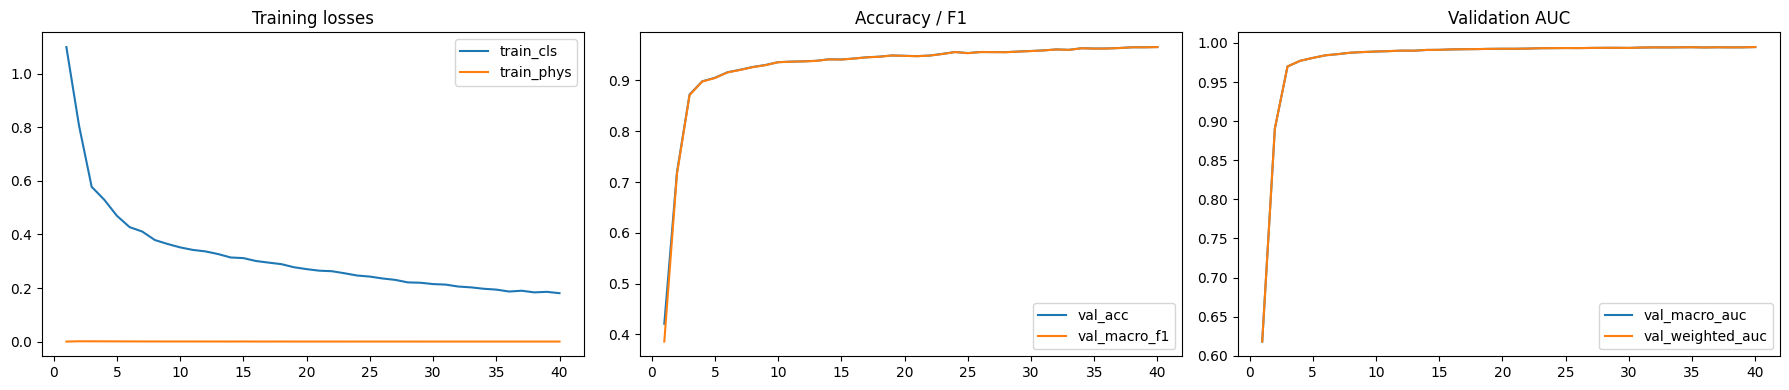

saved: /kaggle/working/outputs_acpt_pinn/plots/training_curves.png
Best checkpoint (no TTA)
{
  "accuracy": 0.9656,
  "macro_f1": 0.9655138254529881,
  "macro_auc_ovr": 0.9947238,
  "weighted_auc_ovr": 0.9947237999999998,
  "per_class_auc": {
    "no": 0.9951172800000001,
    "sphere": 0.99166588,
    "vort": 0.9973882399999999
  }
}
              precision    recall  f1-score   support

          no    0.94299   0.99240   0.96706      2500
      sphere    0.97819   0.93280   0.95495      2500
        vort    0.97746   0.97160   0.97452      2500

    accuracy                        0.96560      7500
   macro avg    0.96621   0.96560   0.96551      7500
weighted avg    0.96621   0.96560   0.96551      7500



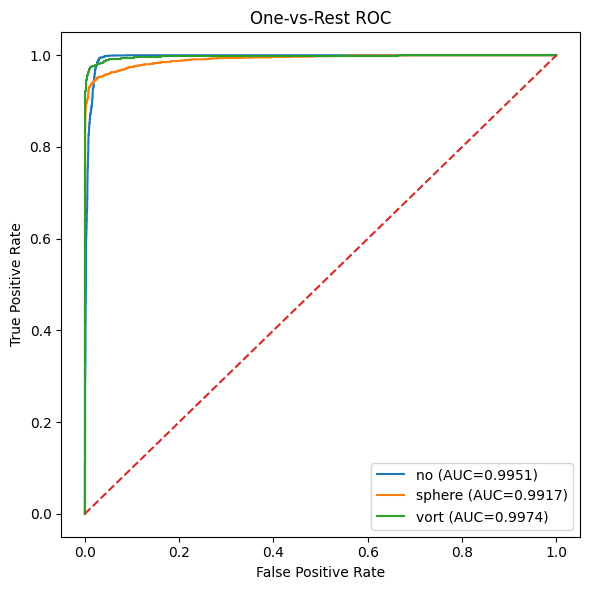

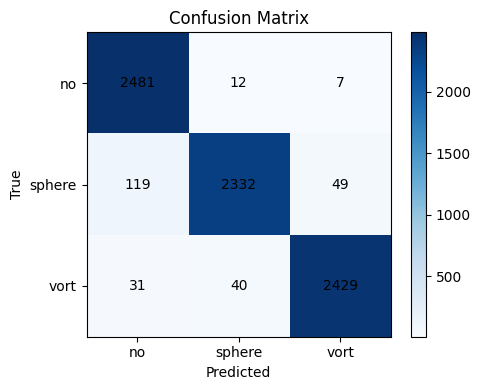

   macro_auc_ovr                                          ckpt_path
0       0.994724  /kaggle/working/outputs_acpt_pinn/checkpoints/...
1       0.994506  /kaggle/working/outputs_acpt_pinn/checkpoints/...
2       0.994443  /kaggle/working/outputs_acpt_pinn/checkpoints/...
3       0.994387  /kaggle/working/outputs_acpt_pinn/checkpoints/...
4       0.994372  /kaggle/working/outputs_acpt_pinn/checkpoints/...
topk_ckpt_d4_tta_ensemble
{
  "accuracy": 0.9688,
  "macro_f1": 0.9687363756313273,
  "macro_auc_ovr": 0.9959340266666666,
  "weighted_auc_ovr": 0.9959340266666666,
  "per_class_auc": {
    "no": 0.9958552799999999,
    "sphere": 0.99344152,
    "vort": 0.9985052799999999
  }
}
              precision    recall  f1-score   support

          no    0.94073   0.99680   0.96795      2500
      sphere    0.98316   0.93400   0.95795      2500
        vort    0.98506   0.97560   0.98031      2500

    accuracy                        0.96880      7500
   macro avg    0.96965   0.96880   0.968

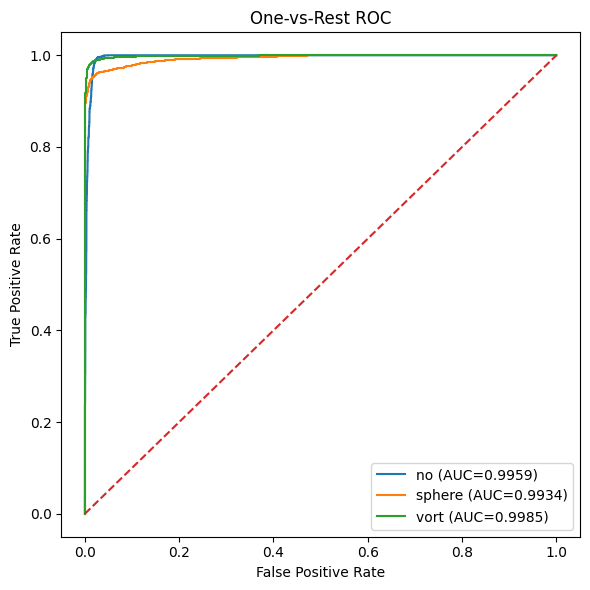

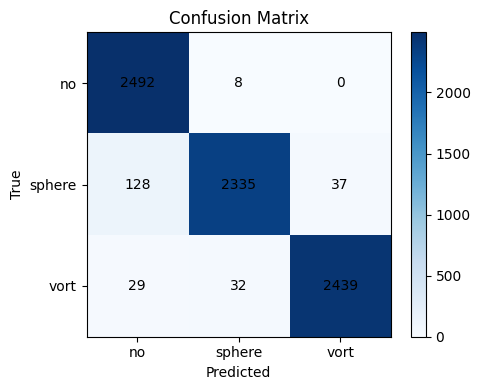

In [ ]:

def load_checkpoint_into_model(model, ckpt_path, use_ema=True):
    obj = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(obj["model_state"], strict=True)
    if use_ema and "ema_shadow" in obj:
        state = model.state_dict()
        for k, v in obj["ema_shadow"].items():
            if k in state:
                state[k].copy_(v)
    return obj

@torch.no_grad()
def evaluate_checkpoint(ckpt_path, use_tta=True):
    m = ACPTPINN(cfg).to(device)
    load_checkpoint_into_model(m, ckpt_path, use_ema=True)
    metrics, pred_df = evaluate(m, val_loader, use_tta=use_tta)
    return metrics, pred_df

def plot_history(hist_df):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(hist_df["epoch"], hist_df["train_cls"], label="train_cls")
    axes[0].plot(hist_df["epoch"], hist_df["train_phys"], label="train_phys")
    axes[0].set_title("Training losses")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
    axes[1].plot(hist_df["epoch"], hist_df["val_macro_f1"], label="val_macro_f1")
    axes[1].set_title("Accuracy / F1")
    axes[1].legend()

    axes[2].plot(hist_df["epoch"], hist_df["val_macro_auc"], label="val_macro_auc")
    axes[2].plot(hist_df["epoch"], hist_df["val_weighted_auc"], label="val_weighted_auc")
    axes[2].set_title("Validation AUC")
    axes[2].legend()

    plt.tight_layout()
    path = Path(cfg.plot_dir) / "training_curves.png"
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    print("saved:", path)

def plot_roc(labels, probs, out_path):
    y_bin = label_binarize(labels, classes=list(range(cfg.num_classes)))
    plt.figure(figsize=(6, 6))
    for i in range(cfg.num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        auc_i = roc_auc_score(y_bin[:, i], probs[:, i])
        plt.plot(fpr, tpr, label=f"{ID_TO_CLASS[i]} (AUC={auc_i:.4f})")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("One-vs-Rest ROC")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()

def plot_confusion(cm, out_path):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(cfg.num_classes))
    ax.set_yticks(range(cfg.num_classes))
    ax.set_xticklabels([ID_TO_CLASS[i] for i in range(cfg.num_classes)])
    ax.set_yticklabels([ID_TO_CLASS[i] for i in range(cfg.num_classes)])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    fig.colorbar(im)
    plt.tight_layout()
    plt.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()

hist_df = pd.read_csv(Path(cfg.output_dir) / "training_history.csv")
plot_history(hist_df)

best_ckpt = str(Path(cfg.output_dir) / "best_acpt_pinn.pth")
best_metrics, best_pred_df = evaluate_checkpoint(best_ckpt, use_tta=False)
save_json(best_metrics, Path(cfg.output_dir) / "best_checkpoint_metrics_no_tta.json")
best_pred_df.to_csv(Path(cfg.output_dir) / "best_checkpoint_val_predictions_no_tta.csv", index=False)

print("Best checkpoint (no TTA)")
print(json.dumps({k: v for k, v in best_metrics.items() if k not in ['report', 'cm']}, indent=2))
print(best_metrics["report"])

labels = best_pred_df["label"].values
probs = best_pred_df[["prob_no", "prob_sphere", "prob_vort"]].values
plot_roc(labels, probs, Path(cfg.plot_dir) / "best_checkpoint_roc_no_tta.png")
plot_confusion(best_metrics["cm"], Path(cfg.plot_dir) / "best_checkpoint_cm_no_tta.png")


# Top-k + D4 TTA ensemble
topk_df = pd.read_csv(Path(cfg.output_dir) / "topk_checkpoints.csv")
print(topk_df)

@torch.no_grad()
def ensemble_predict(checkpoint_paths, use_tta=True):
    probs_all = []
    labels_ref = None
    paths_ref = None

    for ckpt in checkpoint_paths:
        m = ACPTPINN(cfg).to(device)
        load_checkpoint_into_model(m, ckpt, use_ema=True)
        probs, labels, paths = predict_proba(m, val_loader, use_tta=use_tta)
        probs_all.append(probs)
        if labels_ref is None:
            labels_ref = labels
            paths_ref = paths

    probs_ens = np.mean(probs_all, axis=0)
    pred_df = pd.DataFrame({
        "path": paths_ref,
        "label": labels_ref,
        "pred": probs_ens.argmax(axis=1),
        "prob_no": probs_ens[:, 0],
        "prob_sphere": probs_ens[:, 1],
        "prob_vort": probs_ens[:, 2],
    })
    metrics = multiclass_metrics(labels_ref, probs_ens)
    return metrics, pred_df

topk_paths = topk_df["ckpt_path"].tolist()
ens_metrics, ens_pred_df = ensemble_predict(topk_paths, use_tta=cfg.use_d4_tta)

save_json(ens_metrics, Path(cfg.output_dir) / "topk_ckpt_d4_tta_ensemble_metrics.json")
ens_pred_df.to_csv(Path(cfg.output_dir) / "topk_ckpt_d4_tta_ensemble_predictions.csv", index=False)

print("topk_ckpt_d4_tta_ensemble")
print(json.dumps({k: v for k, v in ens_metrics.items() if k not in ['report', 'cm']}, indent=2))
print(ens_metrics["report"])

labels = ens_pred_df["label"].values
probs = ens_pred_df[["prob_no", "prob_sphere", "prob_vort"]].values
plot_roc(labels, probs, Path(cfg.plot_dir) / "topk_ckpt_d4_tta_ensemble_roc.png")
plot_confusion(ens_metrics["cm"], Path(cfg.plot_dir) / "topk_ckpt_d4_tta_ensemble_cm.png")


# Bundle outputs
bundle_path = Path(cfg.output_dir) / "artifact_bundle.zip"
with zipfile.ZipFile(bundle_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(cfg.output_dir):
        for fn in files:
            fp = Path(root) / fn
            if fp == bundle_path:
                continue
            zf.write(fp, arcname=str(fp.relative_to(cfg.output_dir)))

print("saved artifact bundle:", bundle_path)
